# Dynamic Programming

Following **Chapter 4** from *Reinforcement Learning* (edition 2) by Andrew Barto and Richard S. Sutton

### Setup

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [84]:
# Actions
a = {
    0: lambda r, c, shape: (max(0, r-1), c), # Up
    1: lambda r, c, shape: (r, min(shape[0]-1, c+1)), # Right
    2: lambda r, c, shape: (min(shape[0]-1, r+1), c), # Down
    3: lambda r, c, shape: (r, max(0, c-1)), # Left
}
pi = {
    action: 1 / len(a) for action in a
} # Equiprobable stochastic policy

# Grid rewards
grid_shape = (4, 4)
goal_positions = [(0, 0), (3, 3)]

step_reward = -1
goal_reward = 0

reward_map = np.ones(grid_shape) * step_reward 
for pos in goal_positions:
    reward_map[pos] = goal_reward

reward_map

array([[ 0., -1., -1., -1.],
       [-1., -1., -1., -1.],
       [-1., -1., -1., -1.],
       [-1., -1., -1.,  0.]])

### Policy Evaluation & Policy Improvement

Page 74. Figure on page 77.

In [97]:
gamma = 1.0 # Discount

v_k = np.zeros(grid_shape)
v_k_plus_1 = np.zeros(grid_shape)
pi_k = np.full((*grid_shape, len(pi)), list(pi.values()))

for _ in range(1000): # Iteration steps
    # Evaluation
    for row in range(grid_shape[0]):
        for col in range(grid_shape[1]):
            s = (row, col)
            if s in goal_positions:
                continue # skip state-value calculation for goal states - since they have v_pi = 0 axiomatically
            r = reward_map[row, col] # reward 
            # Bellman equation & state-value update
            # Simplified, since transition dynamics are deterministic (s',r|s,a)
            v_k_plus_1[s] = sum(pi_k[s][action] * (r + gamma * v_k[a[action](row, col, grid_shape)]) for action in a.keys()) 
    v_k = v_k_plus_1.copy()

print(v_k)

[[  0. -14. -20. -22.]
 [-14. -18. -20. -20.]
 [-20. -20. -18. -14.]
 [-22. -20. -14.   0.]]


### Policy Iteration

Appended to Policy Evaluation code (copy-pasted from above), Code is not exactly the same as the book pseudocode - I was experimenting

In [105]:
gamma = 1.0 # Discount

v_k = np.zeros(grid_shape)
v_k_plus_1 = np.zeros(grid_shape)
pi_k = np.full((*grid_shape, len(pi)), list(pi.values()))

for _ in range(1000): # Iteration steps
    # Evaluation
    for row in range(grid_shape[0]):
        for col in range(grid_shape[1]):
            s = (row, col)
            if s in goal_positions:
                continue # skip state-value calculation for goal states - since they have v_pi = 0 axiomatically
            r = reward_map[row, col] # reward 
            # Bellman equation & state-value update
            # Simplified, since transition dynamics are deterministic (s',r|s,a)
            v_k_plus_1[s] = sum(pi_k[s][action] * (r + gamma * v_k[a[action](row, col, grid_shape)]) for action in a.keys()) 
    v_k = v_k_plus_1.copy()

    # Improvement
    for row in range(grid_shape[0]):
        for col in range(grid_shape[1]):
            s = (row, col)
            if s in goal_positions:
                continue # skip state-value calculation for goal states - since they have v_pi = 0 axiomatically
            r = reward_map[row, col]
            q_values = []
            for action in a.keys():
                s_prime = a[action](row, col, grid_shape)
                q_values.append(r + gamma * v_k[s_prime])

            best_q = max(q_values)
            best_actions = [1.0 if q == best_q else 0.0 for q in q_values]
            num_best = sum(best_actions)
            pi_k[s] = [b / num_best for b in best_actions]
                
print(pi_k)

[[[0.25 0.25 0.25 0.25]
  [0.   0.   0.   1.  ]
  [0.   0.   0.   1.  ]
  [0.   0.   0.5  0.5 ]]

 [[1.   0.   0.   0.  ]
  [0.5  0.   0.   0.5 ]
  [0.25 0.25 0.25 0.25]
  [0.   0.   1.   0.  ]]

 [[1.   0.   0.   0.  ]
  [0.25 0.25 0.25 0.25]
  [0.   0.5  0.5  0.  ]
  [0.   0.   1.   0.  ]]

 [[0.5  0.5  0.   0.  ]
  [0.   1.   0.   0.  ]
  [0.   1.   0.   0.  ]
  [0.25 0.25 0.25 0.25]]]


### Jack's Car Rental

In [40]:
MAX_CARS = 20
MAX_MOVE = 5
LOCATIONS = 2

state_space_size = tuple([MAX_CARS + 1] * LOCATIONS)
state_space_size

(21, 21)

In [43]:
# Actions
A = np.arange(-MAX_MOVE, MAX_MOVE + 1)

# Environment - transition dynamics

def build_truncated_poisson_cache(lambdas, upper_bound):
    from math import exp, factorial

    cache = {}

    for lam in lambdas:
        probs = np.zeros(upper_bound)

        cumulative = 0.0

        for n in range(upper_bound - 1):
            p = (lam ** n) * exp(-lam) / factorial(n)
            probs[n] = p
            cumulative += p

        # absorb remaining tail probability
        probs[upper_bound - 1] = 1.0 - cumulative

        cache[lam] = probs

    return cache

poisson = lambda n, lam: (lam**n / math.factorial(n)) * math.e**(-lam)
REQUEST_LAMBDAS = [3, 4] # Location 1, 2
RETURN_LAMBDAS = [3, 2]  # Location 1, 2
POISSON_UPPER_BOUND = 11 # The number of requests or returns in a single day we are considering. Given than LAMBDAS are expected averages, this number has to be higher
# For lambdas of 2, 3, 4 , the probability of 11 requests or returns is very small - esentially 0
poisson_cache = build_truncated_poisson_cache( 
    set(REQUEST_LAMBDAS + RETURN_LAMBDAS),
    POISSON_UPPER_BOUND
) # Precomputed poisson probabilities for every (reasonably) possible number of returns or requests per day

# Rewards
def request_reward_fn(num_rented: int) -> float:
    return 10 * num_rented

def car_move_reward_fn(num_moved: int) -> float:
    return -2 * num_moved

In [44]:
def get_valid_actions(s):
    """
    Action a:
        +a => move cars from loc1 -> loc2
        -a => move cars from loc2 -> loc1
    """

    return [
        a for a in A
        if (
            0 <= s[0] - a <= MAX_CARS and
            0 <= s[1] + a <= MAX_CARS
        )
    ]

def compute_reward_and_next_state_probs(
    s: tuple[int, int],
    a: int
) -> tuple[np.ndarray, float]:

    if a not in get_valid_actions(s):
        raise ValueError(f"Invalid action {a} for state {s}")

    next_state_probs_per_location = np.zeros(
        (LOCATIONS, MAX_CARS + 1)
    )

    expected_reward_per_location = np.zeros(LOCATIONS)

    next_cars_per_location = np.zeros(
        LOCATIONS,
        dtype=int
    )

    # Execute overnight move
    if a >= 0:
        # loc1 -> loc2
        next_cars_per_location[0] = s[0] - a
        next_cars_per_location[1] = s[1] + a
    else:
        # loc2 -> loc1
        move = abs(a)
        next_cars_per_location[1] = s[1] - move
        next_cars_per_location[0] = s[0] + move

    move_reward = car_move_reward_fn(abs(a))

    # Rental / return dynamics
    for loc_idx in range(LOCATIONS):

        req_lam = REQUEST_LAMBDAS[loc_idx]
        ret_lam = RETURN_LAMBDAS[loc_idx]

        available_cars = next_cars_per_location[loc_idx]

        for req in range(POISSON_UPPER_BOUND):

            p_req = poisson_cache[req_lam][req]

            # cannot rent more than available
            actual_rentals = min(available_cars, req)

            rental_reward = request_reward_fn(actual_rentals)

            for ret in range(POISSON_UPPER_BOUND):

                p_ret = poisson_cache[ret_lam][ret]

                joint_prob = p_req * p_ret

                next_num_cars = min(
                    available_cars - actual_rentals + ret,
                    MAX_CARS
                )

                next_state_probs_per_location[
                    loc_idx,
                    next_num_cars
                ] += joint_prob

                expected_reward_per_location[loc_idx] += (
                    joint_prob * rental_reward
                )

    # Combine location transition probabilities
    joint_next_state_probs = np.outer(
        next_state_probs_per_location[0],
        next_state_probs_per_location[1]
    )

    # Numerical sanity check
    assert np.isclose(
        joint_next_state_probs.sum(),
        1.0,
        atol=1e-10
    ), f"Transition probabilities sum to {joint_next_state_probs.sum()}"

    total_reward = (
        move_reward +
        expected_reward_per_location.sum()
    )

    return joint_next_state_probs, total_reward

In [45]:
def initialization():
    theta = 1e-3
    gamma = 0.9

    V_s = np.zeros(state_space_size)
    PI_s = np.zeros(state_space_size, dtype=int)

    return V_s, PI_s, gamma, theta

def policy_evaluation(
    V_s,
    PI_s,
    gamma,
    state_space_size,
    theta
):

    while True:

        delta = 0.0

        for i in range(state_space_size[0]):
            for j in range(state_space_size[1]):

                s = (i, j)

                a = PI_s[s]

                next_state_probs, r = (
                    compute_reward_and_next_state_probs(s, a)
                )

                v_old = V_s[s]

                # In-place (Gauss-Seidel) update
                V_s[s] = (
                    r +
                    gamma * np.sum(next_state_probs * V_s)
                )

                delta = max(
                    delta,
                    abs(v_old - V_s[s])
                )

        if delta < theta:
            break

    return V_s


def policy_improvement(
    V_s,
    PI_s,
    gamma,
    state_space_size
):

    policy_stable = True

    for i in range(state_space_size[0]):
        for j in range(state_space_size[1]):

            s = (i, j)

            old_action = PI_s[s]

            valid_actions = get_valid_actions(s)

            q_sa_candidates = {}

            for a in valid_actions:

                next_state_probs, r = (
                    compute_reward_and_next_state_probs(s, int(a))
                )

                q_sa = (
                    r +
                    gamma * np.sum(next_state_probs * V_s)
                )

                q_sa_candidates[a] = q_sa

            # deterministic tie-breaking
            best_q = max(q_sa_candidates.values())

            best_actions = [
                a for a, q in q_sa_candidates.items()
                if np.isclose(q, best_q)
            ]

            best_action = min(best_actions)

            PI_s[s] = best_action

            if best_action != old_action:
                policy_stable = False

    return PI_s, policy_stable


def policy_iteration():

    V_s, PI_s, gamma, theta = initialization()

    iteration = 0

    while True:

        print(f"Policy Iteration Step {iteration}")

        V_s = policy_evaluation(
            V_s,
            PI_s,
            gamma,
            state_space_size,
            theta
        )

        PI_s, policy_stable = policy_improvement(
            V_s,
            PI_s,
            gamma,
            state_space_size
        )

        if policy_stable:
            break

        iteration += 1

    return V_s, PI_s


def plot_policy(PI_s):

    actions_grid = np.array(PI_s).reshape(state_space_size)

    fig, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(
        actions_grid,
        cmap='coolwarm',
        origin='lower'
    )

    for i in range(actions_grid.shape[0]):
        for j in range(actions_grid.shape[1]):

            ax.text(
                j,
                i,
                actions_grid[i, j],
                ha='center',
                va='center',
                fontsize=7
            )

    ax.set_title("Jack's Car Rental Optimal Policy")

    ax.set_xlabel("Cars at Location 2")
    ax.set_ylabel("Cars at Location 1")

    ax.set_xticks(np.arange(actions_grid.shape[1]))
    ax.set_yticks(np.arange(actions_grid.shape[0]))

    fig.colorbar(
        im,
        ax=ax,
        label='Cars moved overnight'
    )

    plt.tight_layout()
    plt.show()


In [46]:
V_s, PI_s = policy_iteration()

Policy Iteration Step 0
Policy Iteration Step 1
Policy Iteration Step 2
Policy Iteration Step 3
Policy Iteration Step 4
Policy Iteration Step 5


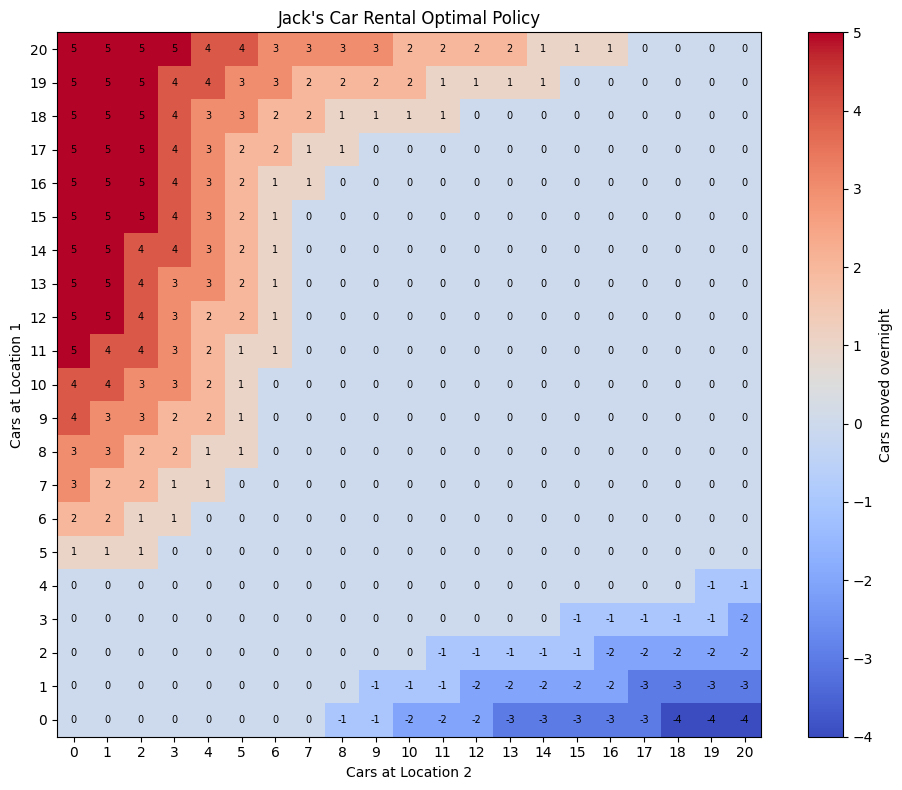

In [47]:
plot_policy(PI_s)

### Value Iteration - Gambler's Problem

Page 84 - Exercise 4.9

In [66]:
MIN_CAPITAL = 0
MAX_CAPITAL = 100
num_states = MAX_CAPITAL - MIN_CAPITAL + 1

In [67]:
def coinflip(p_head: float) -> str:
    return 'heads' if np.random.rand() < p_head else 'tails'

In [ ]:
def initialize_gamblers_problem(num_states: int) -> tuple[np.ndarray, float, float]:
    theta = 1e-3 # Convergence threshold
    gamma = 1.0 # Discount factor (1.0 = undiscounted)
    V_s = np.zeros(num_states) # State value function

    return V_s, gamma, theta

In [75]:
def value_iteration(num_states: int, p_head: float):
    V_s, gamma, theta = initialize_gamblers_problem(num_states)

    while True:
        V_s_new = V_s.copy()
        delta = 0
        for s in range(1, V_s.size - 1):
            actions = np.arange(1, min(s, MAX_CAPITAL - s) + 1)
            q_values = []
            for a in actions:
                reward = 1 if s + a == MAX_CAPITAL else 0
                q = p_head * (reward + gamma * V_s[s + a]) + (1 - p_head) * (gamma * V_s[s - a])
                q_values.append(q)
            V_s_new[s] = max(q_values)
            delta = max(delta, abs(V_s[s] - V_s_new[s]))
        V_s = V_s_new.copy()
        if delta <= theta:
            break
    
    return V_s

In [77]:
def extract_policy(V_s: np.ndarray, p_head: float, gamma: float = 1.0):
    """
    Extract the optimal policy from a converged value function.
    
    Returns
    -------
    policy : np.ndarray
        Optimal stake for each state.
    """
    policy = np.zeros(MAX_CAPITAL + 1, dtype=int)

    for s in range(1, MAX_CAPITAL):
        actions = np.arange(1, min(s, MAX_CAPITAL - s) + 1)

        q_values = []
        for a in actions:
            reward = 1 if s + a == MAX_CAPITAL else 0

            q = (
                p_head * (reward + gamma * V_s[s + a]) +
                (1 - p_head) * (gamma * V_s[s - a])
            )

            q_values.append(q)

        # Choose the action with highest value
        best_action = actions[np.argmax(q_values)]
        policy[s] = best_action

    return policy


def plot_gamblers_results(V_s: np.ndarray, p_head: float, gamma: float = 1.0):
    """
    Plot:
    1. Final value function
    2. Final optimal policy
    """

    policy = extract_policy(V_s, p_head, gamma)

    states = np.arange(MAX_CAPITAL + 1)

    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    # ----- Value Function -----
    axes[0].plot(states, V_s, linewidth=2)
    axes[0].set_title("Value Function")
    axes[0].set_xlabel("Capital")
    axes[0].set_ylabel("Value Estimate")
    axes[0].grid(True)

    # ----- Policy -----
    axes[1].step(states, policy, where="mid")
    axes[1].set_title("Optimal Policy")
    axes[1].set_xlabel("Capital")
    axes[1].set_ylabel("Stake")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

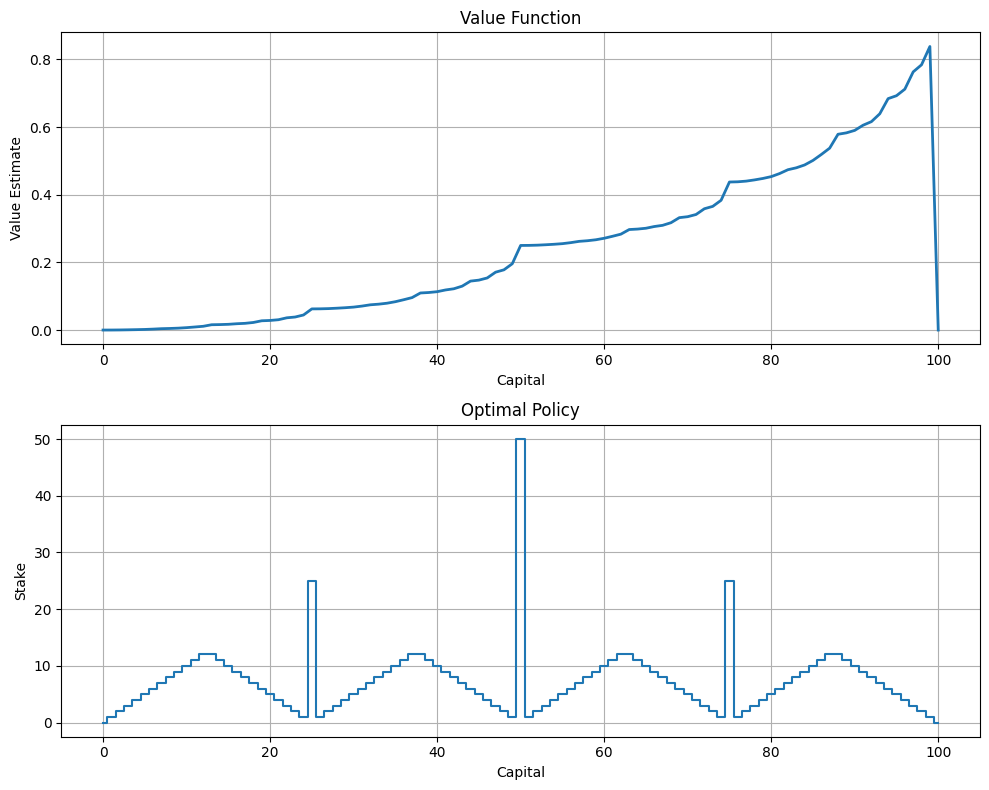

In [80]:
p_head = 0.25
V_s = value_iteration(num_states, p_head)
plot_gamblers_results(V_s, p_head)